<a href="https://colab.research.google.com/github/deepsharma26/SIRT1/blob/Data_collection/Copy_of_CDD_ML_Part_2_Exploratory_Data_Analysis_SIRT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

Chanin Nantasenamat

[*'Data Professor' YouTube channel*](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life **data science project** that you can include in your **data science portfolio**. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

---

## **Install conda and rdkit**

In [ ]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2025-02-03 09:45:42--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:bf9e, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’

Miniconda3-py37_4.8 100%[===================>]  81.12M   132MB/s    in 0.6s    

2025-02-03 09:45:43 (132 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - asn1crypto==1.3.0=py37_0
    - ca-certificates==2020.1.1=0
    - certifi==2019.11.28=py37_0
    - cffi==1.14.0=py37h2e261b9_0
    - chardet==3.0.4=py37_1003
    - conda-package-handling==1.6.0=

## **Load bioactivity data**

In [ ]:
import pandas as pd
df = pd.read_csv('SIRT1_03_bioactivity_data_curated.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL420311,NC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,98.0,active
1,CHEMBL115600,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O,205.0,active
2,CHEMBL112265,NC(=O)C1CCCc2c1[nH]c1ccccc21,1470.0,intermediate
3,CHEMBL446446,NC(=O)C1CCCCc2c1[nH]c1ccc(Cl)cc21,124.0,active
4,CHEMBL171137,CCOC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,100000.0,inactive
...,...,...,...,...
928,CHEMBL4793948,O=C(Nc1ccccc1)Nc1ccc(NC(=O)c2ccccc2)cc1,1200.0,intermediate
929,CHEMBL4749004,O=C(NCCc1c[nH]c2ccccc12)c1cc2ccccc2cc1O,2500.0,intermediate
930,CHEMBL5416344,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2Cl)ncc1C(=O)N...,112600.0,inactive
931,CHEMBL5424599,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2)nc(Nc2ccccc2...,21900.0,inactive


In [ ]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [ ]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [ ]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL420311,98.0,active,NC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21
1,CHEMBL115600,205.0,active,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O
2,CHEMBL112265,1470.0,intermediate,NC(=O)C1CCCc2c1[nH]c1ccccc21
3,CHEMBL446446,124.0,active,NC(=O)C1CCCCc2c1[nH]c1ccc(Cl)cc21
4,CHEMBL171137,100000.0,inactive,CCOC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21
...,...,...,...,...
928,CHEMBL4793948,1200.0,intermediate,O=C(Nc1ccccc1)Nc1ccc(NC(=O)c2ccccc2)cc1
929,CHEMBL4749004,2500.0,intermediate,O=C(NCCc1c[nH]c2ccccc12)c1cc2ccccc2cc1O
930,CHEMBL5416344,112600.0,inactive,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2Cl)ncc1C(=O)N...
931,CHEMBL5424599,21900.0,inactive,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2)nc(Nc2ccccc2...


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [ ]:
!pip install rdkit-pypi
import sys
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors,Lipinski

     |████████████████████████████████| 29.2 MB 1.3 MB/s 


### **Calculate descriptors**

In [ ]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,248.713,2.72650,2.0,1.0
1,228.295,2.38152,2.0,1.0
2,214.268,2.07310,2.0,1.0
3,262.740,3.11660,2.0,1.0
4,277.751,3.80430,1.0,2.0
...,...,...,...,...
928,331.375,4.58290,3.0,2.0
929,330.387,3.99920,3.0,2.0
930,582.130,4.24410,5.0,7.0
931,501.016,3.75300,6.0,8.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [ ]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,248.713,2.72650,2.0,1.0
1,228.295,2.38152,2.0,1.0
2,214.268,2.07310,2.0,1.0
3,262.740,3.11660,2.0,1.0
4,277.751,3.80430,1.0,2.0
...,...,...,...,...
928,331.375,4.58290,3.0,2.0
929,330.387,3.99920,3.0,2.0
930,582.130,4.24410,5.0,7.0
931,501.016,3.75300,6.0,8.0


In [ ]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL420311,NC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,98.0,active
1,CHEMBL115600,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O,205.0,active
2,CHEMBL112265,NC(=O)C1CCCc2c1[nH]c1ccccc21,1470.0,intermediate
3,CHEMBL446446,NC(=O)C1CCCCc2c1[nH]c1ccc(Cl)cc21,124.0,active
4,CHEMBL171137,CCOC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,100000.0,inactive
...,...,...,...,...
928,CHEMBL4793948,O=C(Nc1ccccc1)Nc1ccc(NC(=O)c2ccccc2)cc1,1200.0,intermediate
929,CHEMBL4749004,O=C(NCCc1c[nH]c2ccccc12)c1cc2ccccc2cc1O,2500.0,intermediate
930,CHEMBL5416344,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2Cl)ncc1C(=O)N...,112600.0,inactive
931,CHEMBL5424599,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2)nc(Nc2ccccc2...,21900.0,inactive


Now, let's combine the 2 DataFrame

In [ ]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [ ]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL420311,NC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,98.0,active,248.713,2.72650,2.0,1.0
1,CHEMBL115600,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O,205.0,active,228.295,2.38152,2.0,1.0
2,CHEMBL112265,NC(=O)C1CCCc2c1[nH]c1ccccc21,1470.0,intermediate,214.268,2.07310,2.0,1.0
3,CHEMBL446446,NC(=O)C1CCCCc2c1[nH]c1ccc(Cl)cc21,124.0,active,262.740,3.11660,2.0,1.0
4,CHEMBL171137,CCOC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,100000.0,inactive,277.751,3.80430,1.0,2.0
...,...,...,...,...,...,...,...,...
928,CHEMBL4793948,O=C(Nc1ccccc1)Nc1ccc(NC(=O)c2ccccc2)cc1,1200.0,intermediate,331.375,4.58290,3.0,2.0
929,CHEMBL4749004,O=C(NCCc1c[nH]c2ccccc12)c1cc2ccccc2cc1O,2500.0,intermediate,330.387,3.99920,3.0,2.0
930,CHEMBL5416344,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2Cl)ncc1C(=O)N...,112600.0,inactive,582.130,4.24410,5.0,7.0
931,CHEMBL5424599,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2)nc(Nc2ccccc2...,21900.0,inactive,501.016,3.75300,6.0,8.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [ ]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm',axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [ ]:
df_combined.standard_value.describe()

,standard_value
count,9.330000e+02
mean,7.667297e+04
std,2.996598e+05
min,0.000000e+00
25%,3.030000e+03
50%,2.260000e+04
75%,7.090000e+04
max,6.521000e+06


In [ ]:
-np.log10( (10**-9)* 100000000 )

1.0

In [ ]:
-np.log10( (10**-9)* 10000000000 )

-1.0

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [ ]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL420311,NC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,active,248.713,2.72650,2.0,1.0,98.0
1,CHEMBL115600,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O,active,228.295,2.38152,2.0,1.0,205.0
2,CHEMBL112265,NC(=O)C1CCCc2c1[nH]c1ccccc21,intermediate,214.268,2.07310,2.0,1.0,1470.0
3,CHEMBL446446,NC(=O)C1CCCCc2c1[nH]c1ccc(Cl)cc21,active,262.740,3.11660,2.0,1.0,124.0
4,CHEMBL171137,CCOC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,inactive,277.751,3.80430,1.0,2.0,100000.0
...,...,...,...,...,...,...,...,...
928,CHEMBL4793948,O=C(Nc1ccccc1)Nc1ccc(NC(=O)c2ccccc2)cc1,intermediate,331.375,4.58290,3.0,2.0,1200.0
929,CHEMBL4749004,O=C(NCCc1c[nH]c2ccccc12)c1cc2ccccc2cc1O,intermediate,330.387,3.99920,3.0,2.0,2500.0
930,CHEMBL5416344,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2Cl)ncc1C(=O)N...,inactive,582.130,4.24410,5.0,7.0,112600.0
931,CHEMBL5424599,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2)nc(Nc2ccccc2...,inactive,501.016,3.75300,6.0,8.0,21900.0


In [ ]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,9.330000e+02
mean,7.667297e+04
std,2.996598e+05
min,0.000000e+00
25%,3.030000e+03
50%,2.260000e+04
75%,7.090000e+04
max,6.521000e+06


In [ ]:
df_final = pIC50(df_norm)
df_final

<ipython-input-17-06a84c4558ac>:10: RuntimeWarning: divide by zero encountered in log10
  pIC50.append(-np.log10(molar))


,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL420311,NC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,active,248.713,2.72650,2.0,1.0,7.008774
1,CHEMBL115600,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O,active,228.295,2.38152,2.0,1.0,6.688246
2,CHEMBL112265,NC(=O)C1CCCc2c1[nH]c1ccccc21,intermediate,214.268,2.07310,2.0,1.0,5.832683
3,CHEMBL446446,NC(=O)C1CCCCc2c1[nH]c1ccc(Cl)cc21,active,262.740,3.11660,2.0,1.0,6.906578
4,CHEMBL171137,CCOC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,inactive,277.751,3.80430,1.0,2.0,4.000000
...,...,...,...,...,...,...,...,...
928,CHEMBL4793948,O=C(Nc1ccccc1)Nc1ccc(NC(=O)c2ccccc2)cc1,intermediate,331.375,4.58290,3.0,2.0,5.920819
929,CHEMBL4749004,O=C(NCCc1c[nH]c2ccccc12)c1cc2ccccc2cc1O,intermediate,330.387,3.99920,3.0,2.0,5.602060
930,CHEMBL5416344,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2Cl)ncc1C(=O)N...,inactive,582.130,4.24410,5.0,7.0,3.948462
931,CHEMBL5424599,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2)nc(Nc2ccccc2...,inactive,501.016,3.75300,6.0,8.0,4.659556


In [ ]:
df_final.pIC50.describe()

,pIC50
count,933.000000
mean,inf
std,NaN
min,2.185686
25%,4.149354
50%,4.645892
75%,5.518557
max,inf


Let's write this to CSV file.

In [ ]:
df_final.to_csv('SIRT1_04_bioactivity_data_3class_pIC50.csv')

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [ ]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL420311,NC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,active,248.713,2.72650,2.0,1.0,7.008774
1,CHEMBL115600,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O,active,228.295,2.38152,2.0,1.0,6.688246
3,CHEMBL446446,NC(=O)C1CCCCc2c1[nH]c1ccc(Cl)cc21,active,262.740,3.11660,2.0,1.0,6.906578
4,CHEMBL171137,CCOC(=O)C1CCCc2c1[nH]c1ccc(Cl)cc21,inactive,277.751,3.80430,1.0,2.0,4.000000
5,CHEMBL171955,O=C(O)C1CCCc2c1[nH]c1ccc(Cl)cc21,inactive,249.697,3.32580,2.0,1.0,4.000000
...,...,...,...,...,...,...,...,...
924,CHEMBL2093745,O=C(NCCc1c[nH]c2ccccc12)c1n[nH]c2ccccc12,inactive,304.353,3.01670,3.0,2.0,5.000000
927,CHEMBL5405254,COc1ccc(N2CCN(c3nc(-c4ccccc4)nc4ccccc34)CC2)cc1,inactive,396.494,4.63200,0.0,5.0,4.397940
930,CHEMBL5416344,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2Cl)ncc1C(=O)N...,inactive,582.130,4.24410,5.0,7.0,3.948462
931,CHEMBL5424599,O=C(O)CCNC(=S)NCCCNc1nc(Nc2ccccc2)nc(Nc2ccccc2...,inactive,501.016,3.75300,6.0,8.0,4.659556


Let's write this to CSV file.

In [ ]:
df_2class.to_csv('SIRT1_05_bioactivity_data_2class_pIC50.csv')

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

<ipython-input-32-700d9887f52b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df_2class, edgecolor='black', palette="prism")


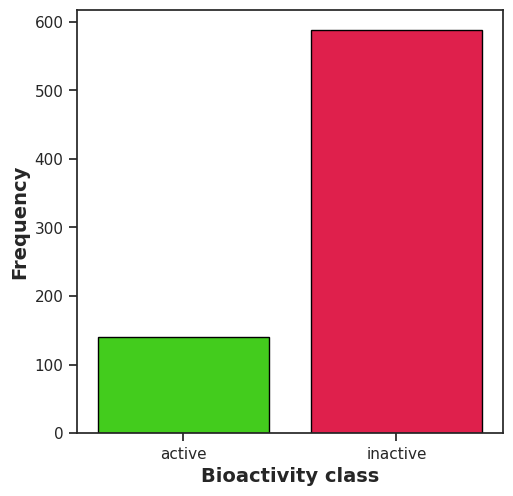

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black', palette="prism")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.rcParams['figure.dpi']=300

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

<ipython-input-34-08242da4742f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2class['pIC50'] = df_2class['pIC50'].replace([np.inf, -np.inf], np.nan)
<ipython-input-34-08242da4742f>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2class['pIC50'] = df_2class['pIC50'].fillna(df_2class['pIC50'].mean())


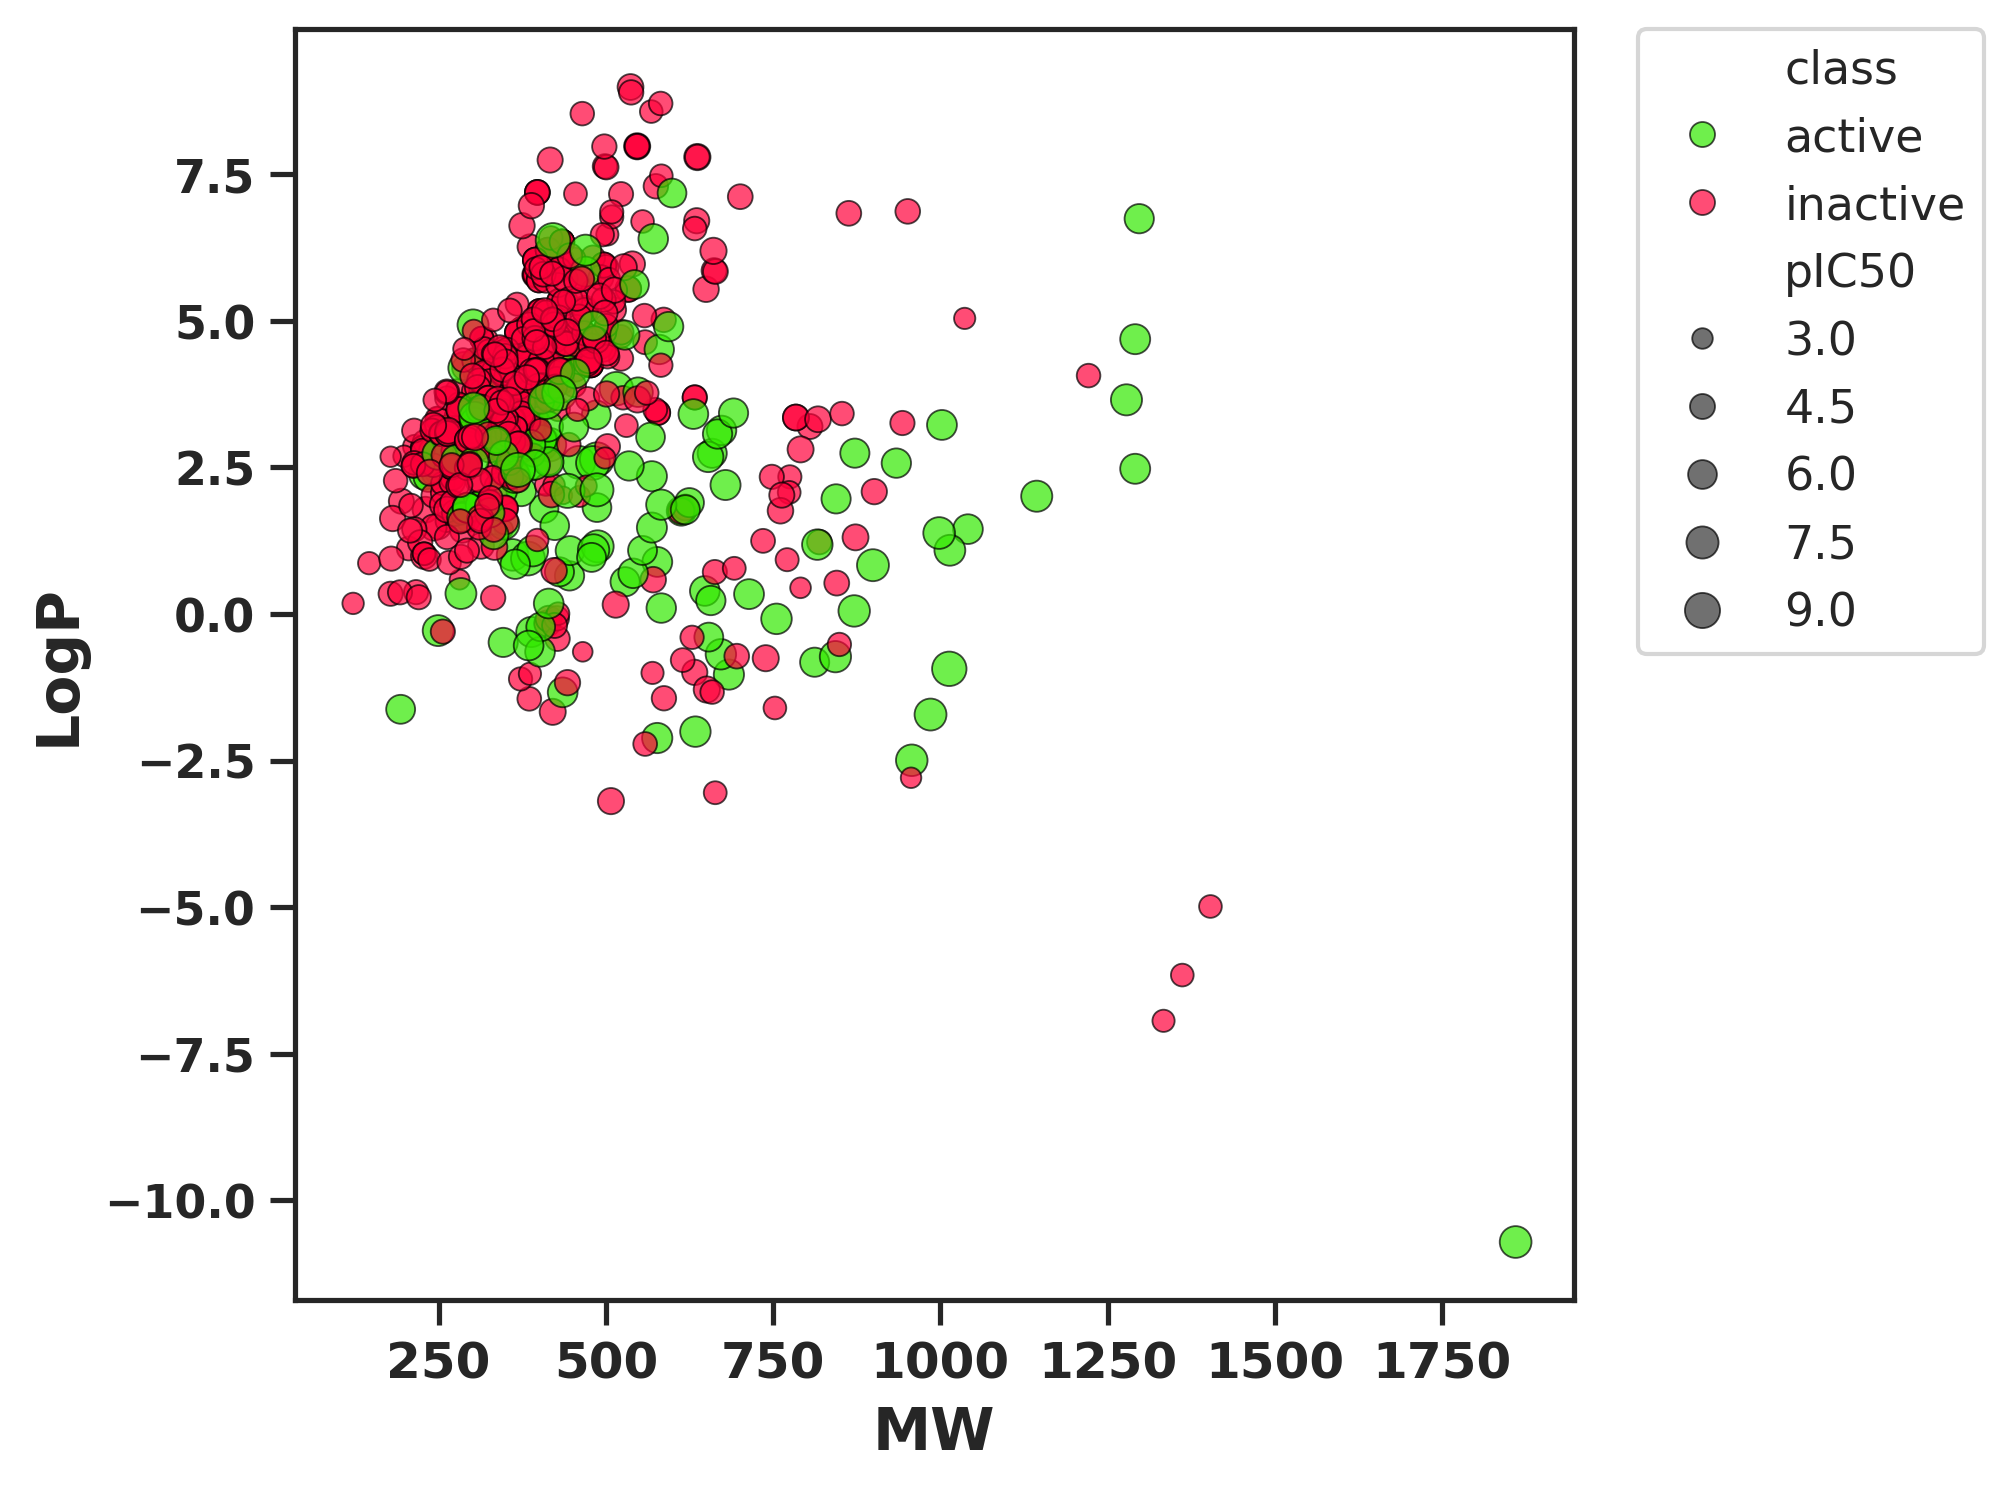

In [ ]:
import numpy as np

# Replace infinite values with large/small finite numbers
df_2class['pIC50'] = df_2class['pIC50'].replace([np.inf, -np.inf], np.nan)

# Replace NaN values with the mean of the column
df_2class['pIC50'] = df_2class['pIC50'].fillna(df_2class['pIC50'].mean())

# Now regenerate the plot
plt.figure(figsize=(5.5, 5.5))
sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', palette='prism', alpha=0.7)
plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold')
plt.rcParams['figure.dpi']=300
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

<ipython-input-38-49f97f0b4074>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'class', y = 'pIC50', data=df_2class, palette="prism")


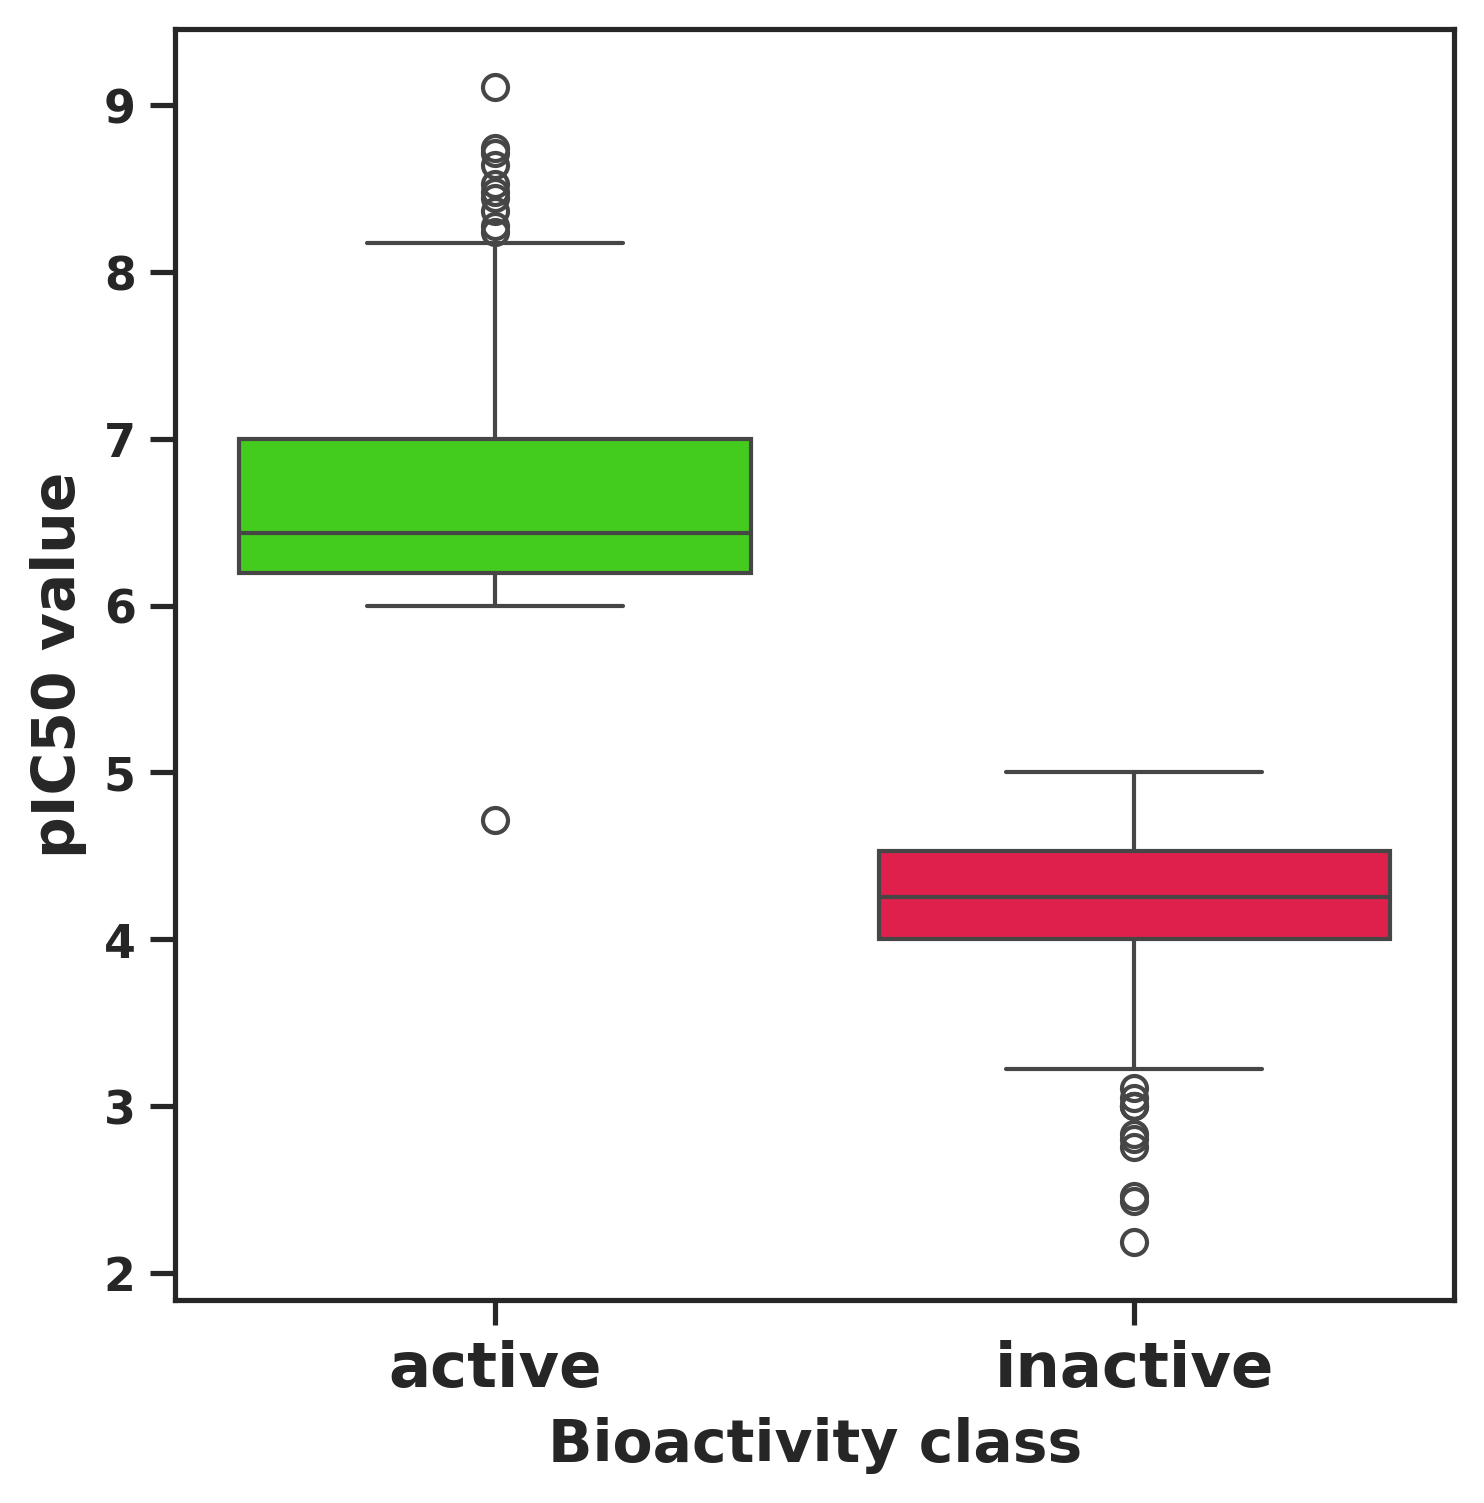

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data=df_2class, palette="prism")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')
plt.xticks(fontweight='bold', fontsize=15)
plt.yticks(fontweight='bold')
plt.rcParams['figure.dpi']=300

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,82812.0,7.413000e-76,0.05,Different distribution (reject H0)


#### **MW**

<ipython-input-42-3fbb9779a3f9>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'class', y = 'MW', data=df_2class, palette="prism")


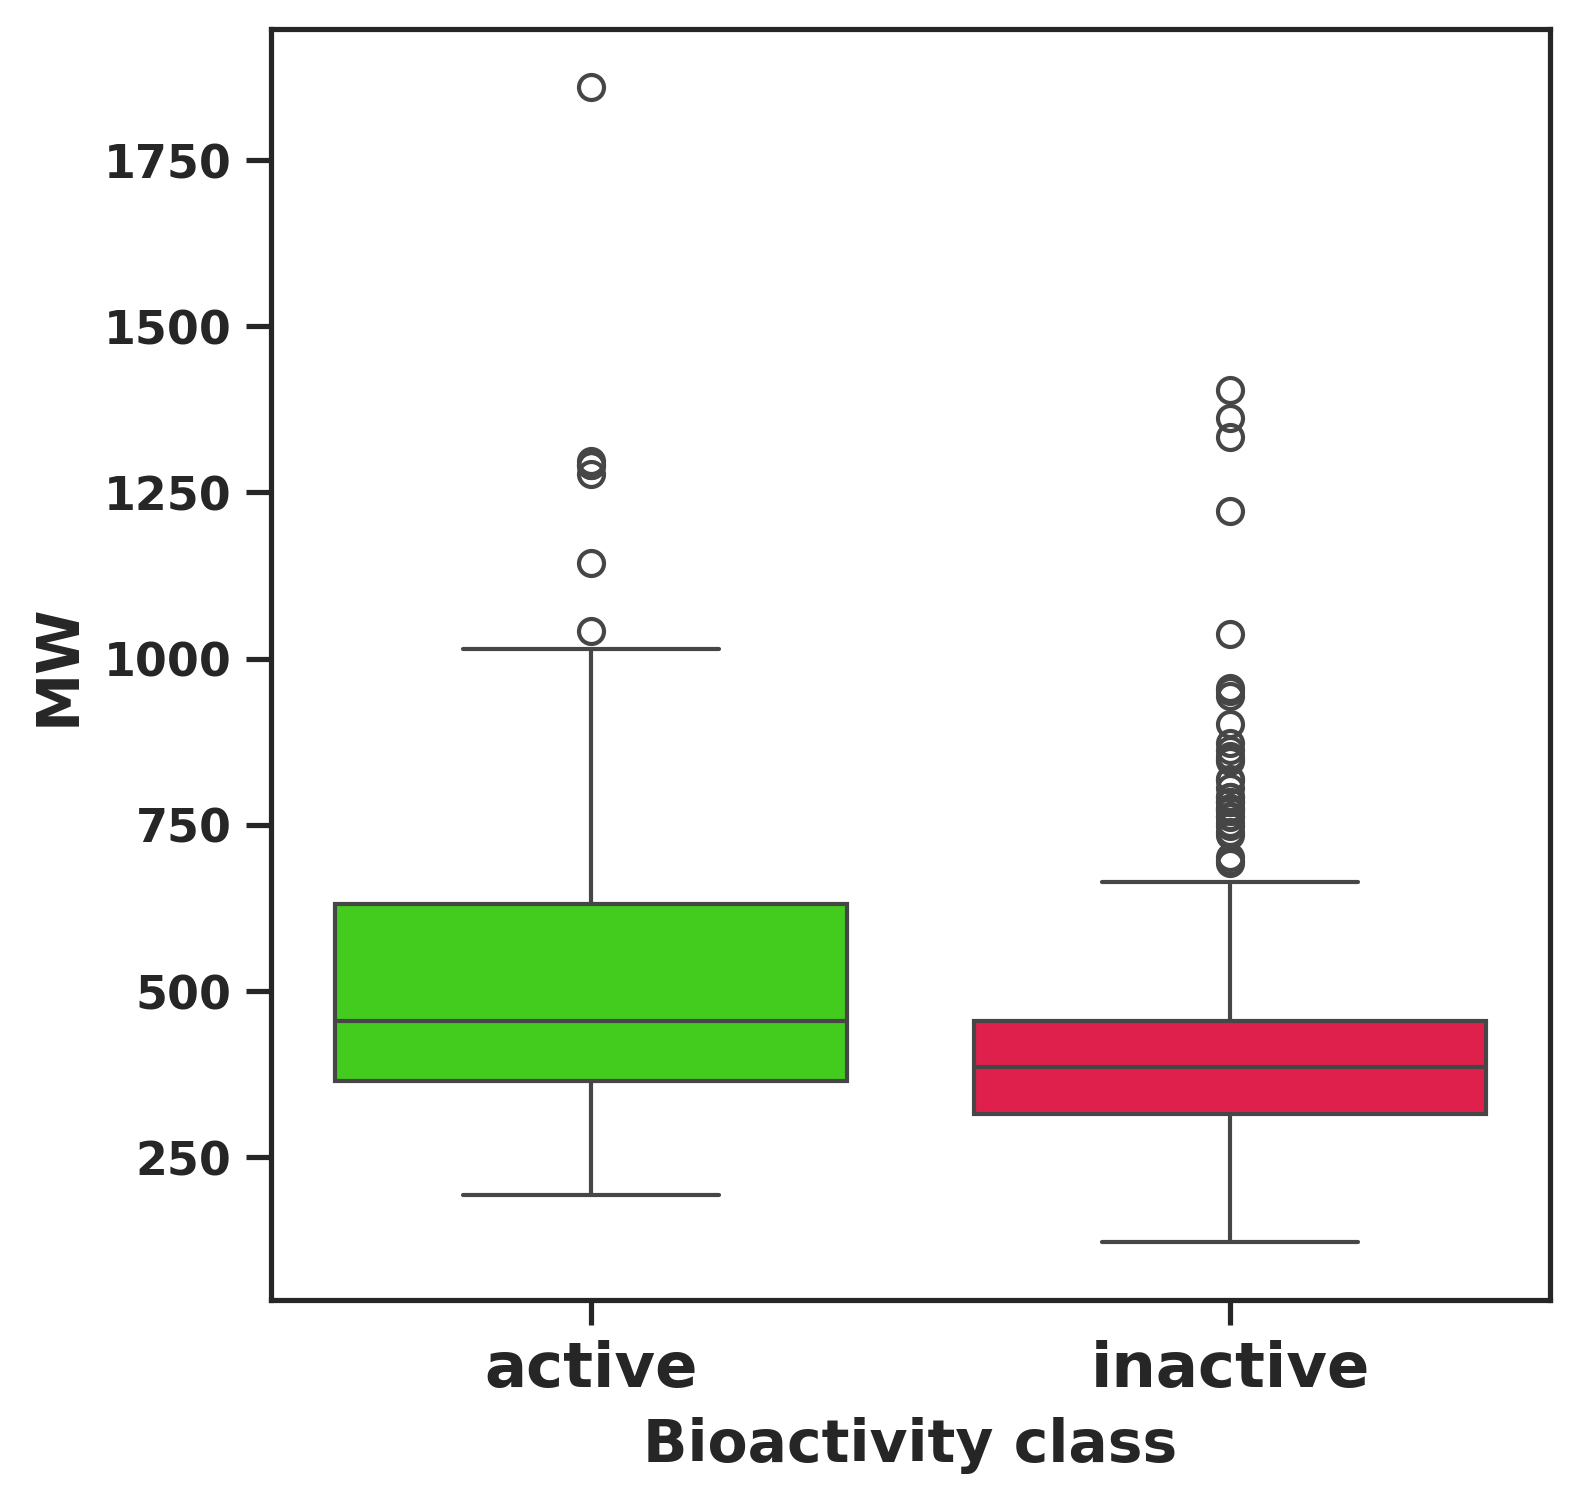

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data=df_2class, palette="prism")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')
plt.xticks(fontweight='bold', fontsize=15)
plt.yticks(fontweight='bold')
plt.rcParams['figure.dpi']=300

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,54591.5,4.926779e-09,0.05,Different distribution (reject H0)


#### **LogP**

<ipython-input-45-edab52ed9fb6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'class', y = 'LogP', data=df_2class, palette="prism")


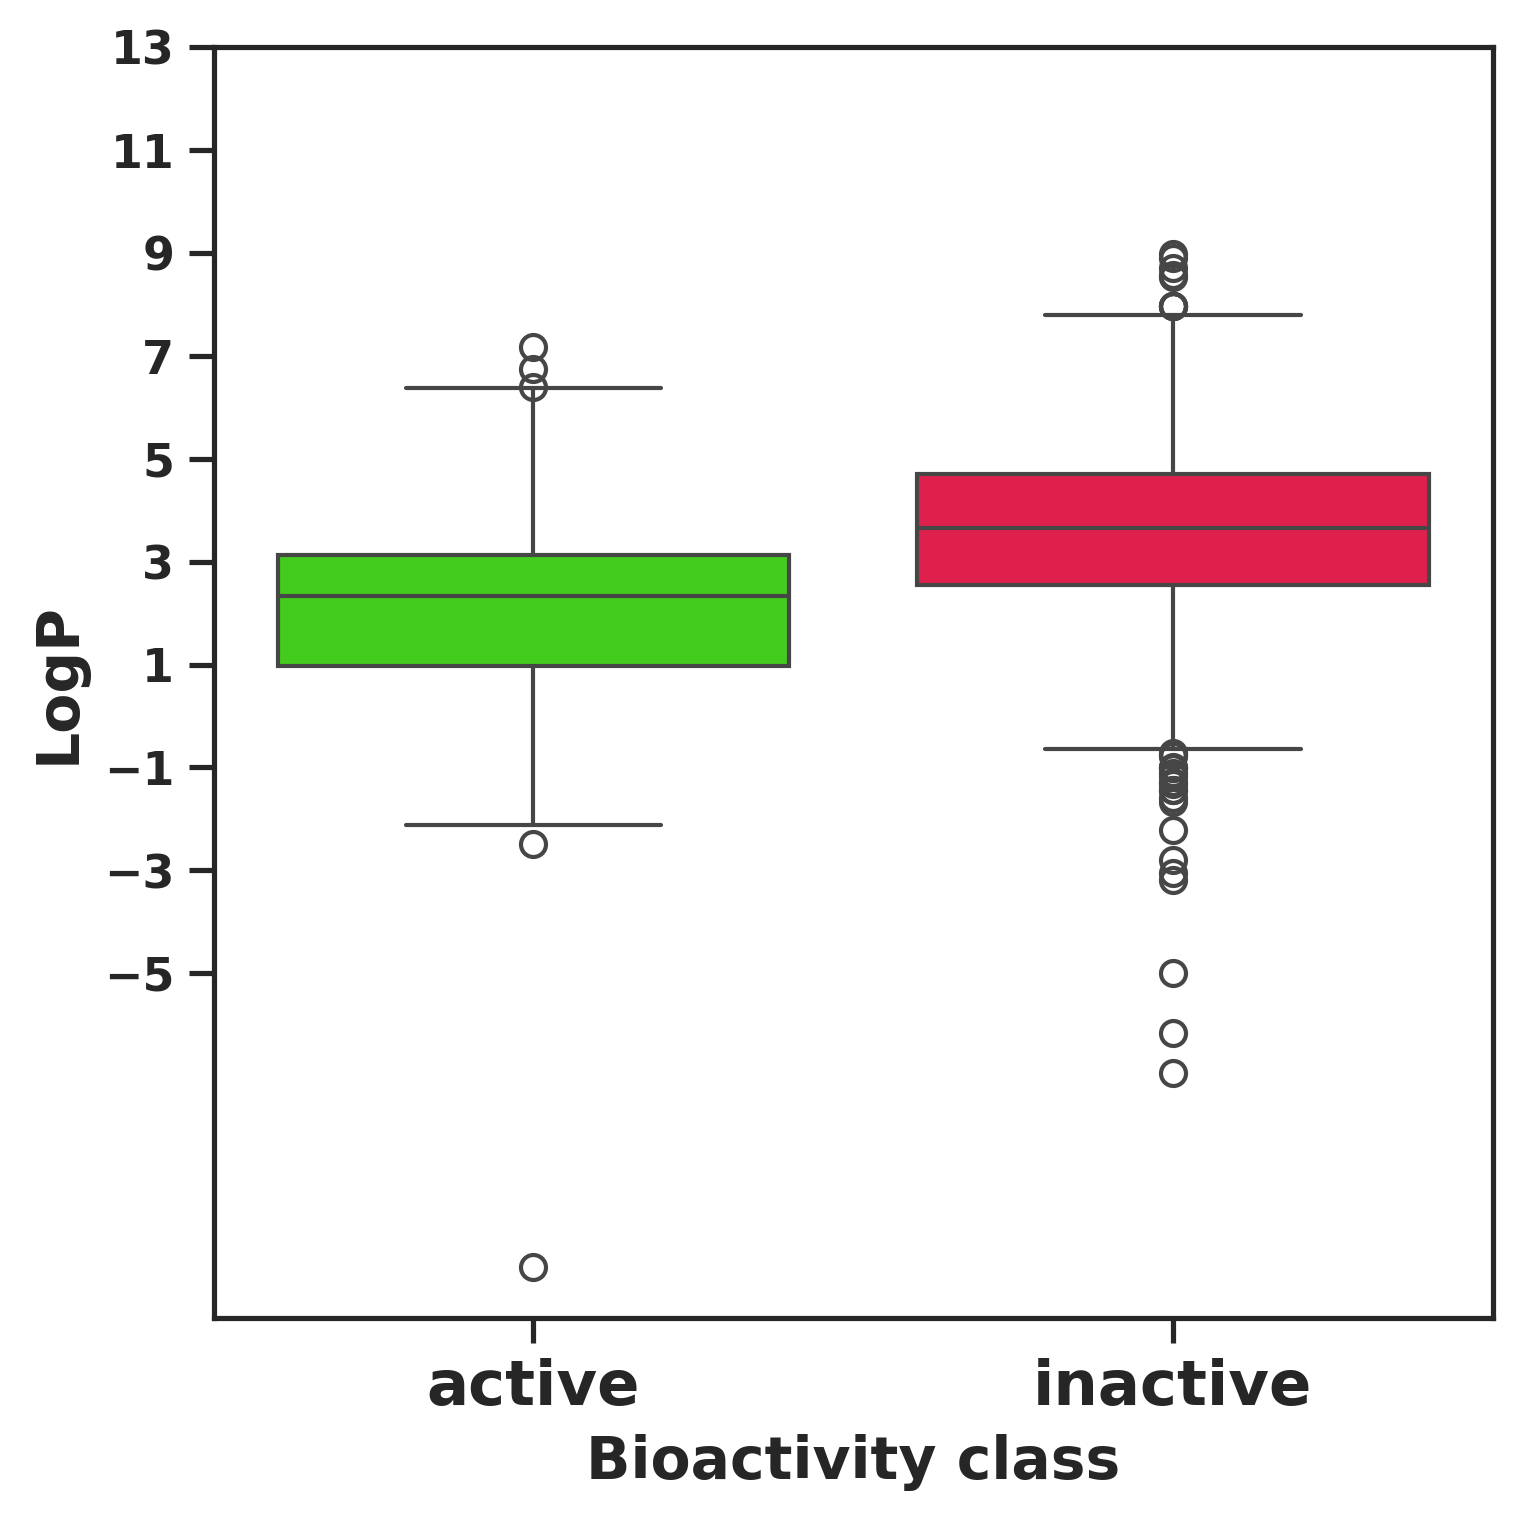

In [ ]:
import numpy as np
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data=df_2class, palette="prism")


listOf_yticks = np.arange(-5, 15, 2)
plt.yticks(listOf_yticks)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.xticks(fontweight='bold', fontsize=15)
plt.yticks(fontweight='bold')
plt.rcParams['figure.dpi']=300

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,22598.5,4.630360e-17,0.05,Different distribution (reject H0)


#### **NumHDonors**

<ipython-input-47-cf2a6e80f1a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'class', y = 'NumHDonors', data=df_2class, palette="prism")


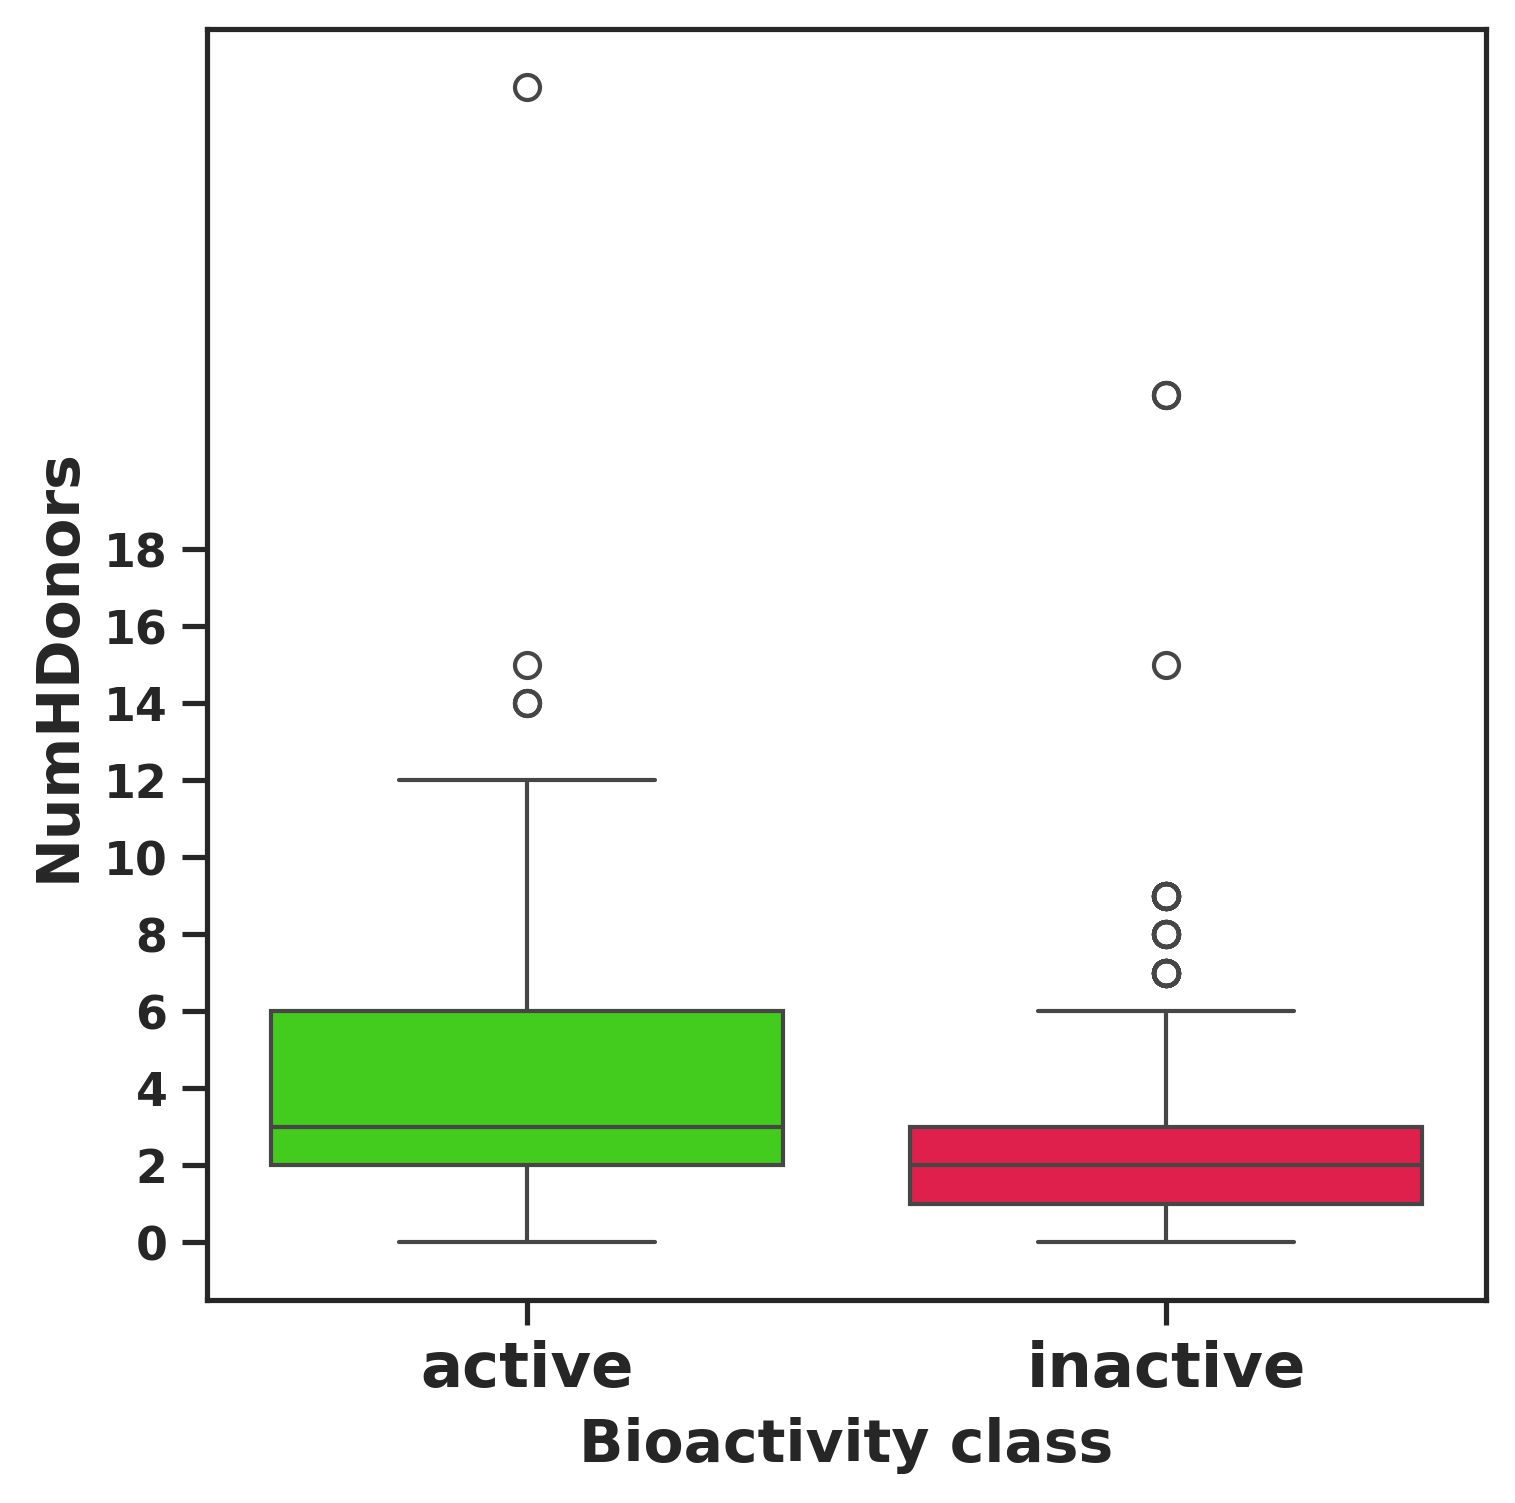

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data=df_2class, palette="prism")

listOf_yticks = np.arange(0, 20, 2)
plt.yticks(listOf_yticks)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')
listOf_yticks = np.arange(0, 20, 2)
listOf_yticks
plt.xticks(fontweight='bold', fontsize=15)
plt.yticks(fontweight='bold')
plt.rcParams['figure.dpi']=300

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,54586.5,2.338883e-09,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

<ipython-input-49-d4c114ebd78a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'class', y = 'NumHAcceptors', data=df_2class, palette="prism")


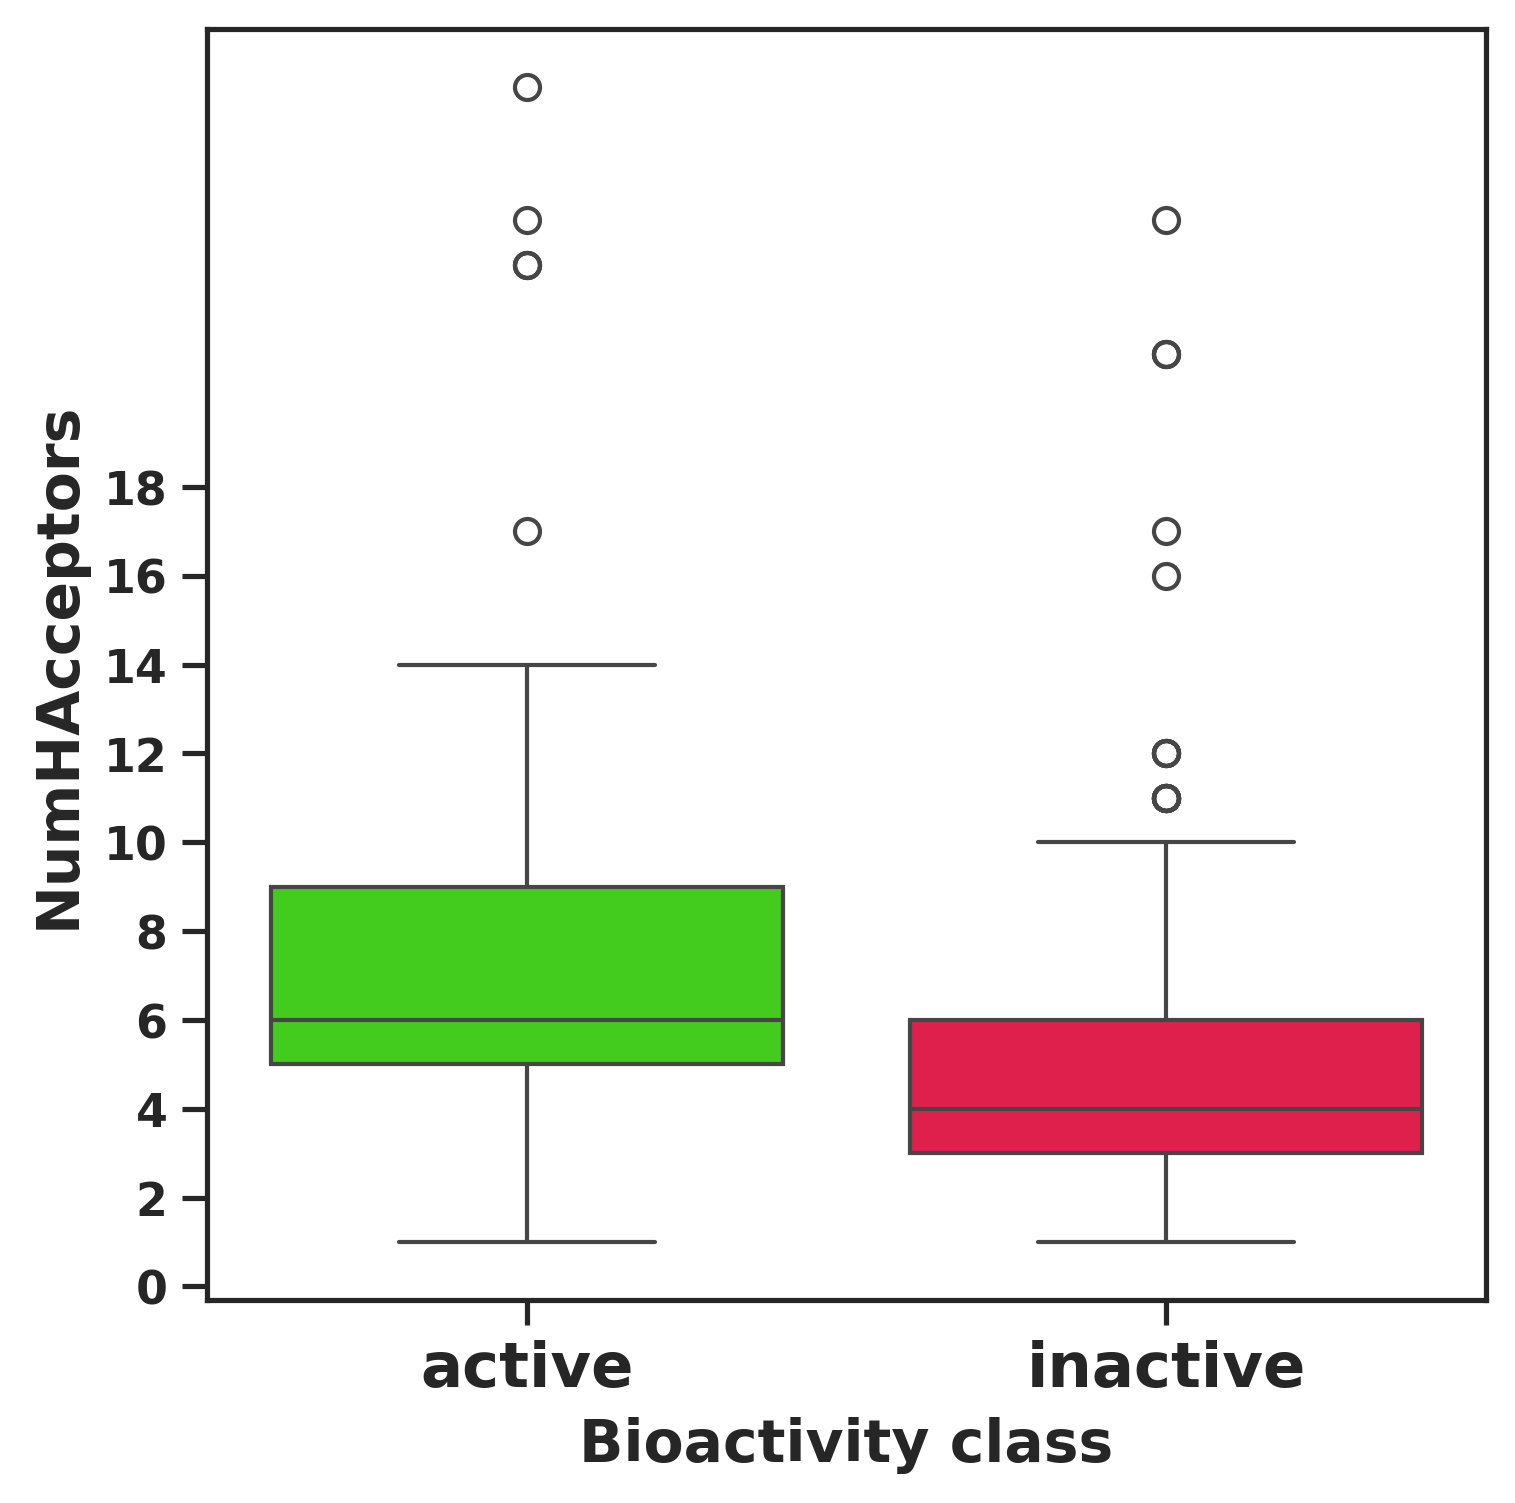

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data=df_2class, palette="prism")
listOf_yticks = np.arange(0, 20, 2)
plt.yticks(listOf_yticks)
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')
plt.xticks(fontweight='bold', fontsize=15)
plt.yticks(fontweight='bold')
plt.rcParams['figure.dpi']=300

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,56924.5,3.379184e-12,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

All of the 4 Lipinski's descriptors exhibited ***statistically significant difference*** between the **actives** and **inactives**.

## **Zip files**

In [ ]:
! zip -r results.zip . -i *.csv *.pdf

  adding: plot_MW_vs_LogP.pdf (deflated 4%)
  adding: SIRT1_03_bioactivity_data_curated.csv (deflated 83%)
  adding: SIRT1_05_bioactivity_data_2class_pIC50.csv (deflated 76%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 11%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: plot_bioactivity_class.pdf (deflated 37%)
  adding: SIRT1_04_bioactivity_data_3class_pIC50.csv (deflated 76%)
  adding: plot_LogP.pdf (deflated 34%)
  adding: plot_NumHAcceptors.pdf (deflated 34%)
  adding: plot_NumHDonors.pdf (deflated 34%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 10%)
  adding: mannwhitneyu_MW.csv (deflated 8%)
  adding: mannwhitneyu_LogP.csv (deflated 9%)
  adding: plot_MW.pdf (deflated 36%)
  adding: plot_ic50.pdf (deflated 33%)
